### Auto-Encoder

This model is constructed very similar to the feed-forward, but made in a separate file to keep the code clean

In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import random

In [2]:
labels = []
numbers = []

with open(os.path.join(os.getcwd(), 'data/MNISTnumLabels5000_balanced.txt'), 'r+') as f:
    lines = f.readlines()
    for line in lines:
        labels.append(int(line))

with open(os.path.join(os.getcwd(), 'data/MNISTnumImages5000_balanced.txt'), 'r+') as f:
    lines = f.readlines()
    for line in lines:
        ind_line = line.split('\t')
        ind_line = [float(i) for i in ind_line]

        numbers.append(ind_line)
    

labels = np.array(labels)
numbers = np.array(numbers)

7


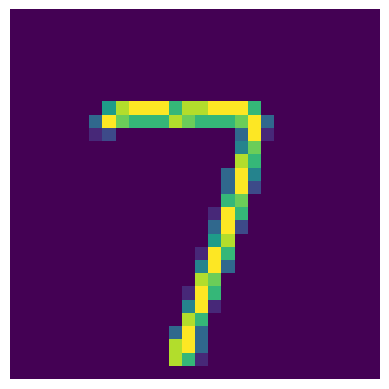

In [3]:
index = random.randint(0, 4999)

example_number = numbers[index]
example_label = labels[index]
matrix = example_number.reshape(28, 28).T

print(example_label)
plt.imshow(matrix)
plt.axis('off')
plt.show()

In [4]:
train_set = []
train_labels = []

test_set = []
test_labels = []

digits = {d: 0 for d in range(0, 10)}

for i in range(len(numbers)):
    label = labels[i]  # get the digit for this image
    
    if label in digits and digits[label] < 400:
        train_set.append(numbers[i])
        train_labels.append(label)
        digits[label] += 1
    else:
        test_set.append(numbers[i])
        test_labels.append(label)
        digits[label] += 1


train_set = np.array(train_set)
test_set = np.array(test_set)
train_labels = np.array(train_labels)
test_labels = np.array(test_labels)
# normalizing the datasets
train_set = train_set.astype(np.float32)
test_set = test_set.astype(np.float32)

combined_train_data = list(zip(train_labels, train_set))
random.shuffle(combined_train_data)

combined_test_data = list(zip(test_labels, test_set))
random.shuffle(combined_test_data)

print(len(combined_train_data), len(combined_test_data))

4000 1000


In [5]:
m, n = train_set.shape

X_train, X_test = train_set, test_set
Y_train, Y_test = train_labels, test_labels

_, m_train = X_train.shape
_, m_test = X_test.shape

In [6]:
# Shuffle training set
perm_train = np.random.permutation(X_train.shape[0])  # columns = samples
X_train = X_train[perm_train]
Y_train = np.array(Y_train)[perm_train]  

# Shuffle test set
perm_test = np.random.permutation(X_test.shape[0])
X_test = X_test[perm_test]
Y_test = np.array(Y_test)[perm_test]

X_train.shape, Y_train.shape

((4000, 784), (4000,))

In [ ]:
class AutoEncoderNet:
    def __init__(self, layers, layer_sizes, momentum=0.9):
        self.layers = layers
        self.layer_sizes = layer_sizes
        self.momentum = momentum

        self.W = []
        self.b = []
        self.vW = []
        self.vb = []

        self.train_mrl_over_epochs = []  # Mean Reconstruction Loss
        
        # Initialize weights and biases
        for i in range(self.layers - 1):
            in_size = layer_sizes[i]
            out_size = layer_sizes[i+1]

            # Xavier/Glorot initialization 
            limit = np.sqrt(6.0 / (in_size + out_size))
            W_i = np.random.uniform(-limit, limit, (in_size, out_size))
            b_i = np.zeros((1, out_size))

            self.W.append(W_i)
            self.b.append(b_i)

            self.vW.append(np.zeros_like(W_i))
            self.vb.append(np.zeros_like(b_i))

    
    ### Activation Functions
    def tanh(self, x):
        return np.tanh(x)
    
    def tanh_deriv(self, x):
        return 1 - np.tanh(x)**2
    
    ### Forward Pass
    def forward(self, x):
        A = x
        A_cache = [A]
        Z_cache = []

        for i in range(self.layers - 1):
            Z = A @ self.W[i] + self.b[i]
            if i < self.layers - 2:  # Hidden layers
                A = self.tanh(Z)
            else: 
                A = self.tanh(Z)
            Z_cache.append(Z)
            A_cache.append(A)

        return A, Z_cache, A_cache
    
    ### Reconstruction Loss (MSE)
    def reconstruction_loss(self, X, Y_reconstructed):
        """
        Calculate mean reconstruction loss for a batch.
        J_q = 0.5 * sum((x_i - y_i)^2)
        """
        # Per-sample loss
        loss_per_sample = 0.5 * np.sum((X - Y_reconstructed)**2, axis=1)
        # Mean over batch
        return np.mean(loss_per_sample)
    
    def reconstruction_loss_per_sample(self, X, Y_reconstructed):
        return 0.5 * np.sum((X - Y_reconstructed)**2, axis=1)
    
    ### Backpropagation
    def backward(self, X_input, Z_cache, A_cache):
        m = X_input.shape[0]

        dW = [None] * (self.layers - 1)
        db = [None] * (self.layers - 1)

        # Output layer gradient
        A_final = A_cache[-1]
        
        # Derivative of loss wrt output: (y_hat - x) * tanh'(z)
        dA = (A_final - X_input) * self.tanh_deriv(Z_cache[-1])

        # Backprop through layers
        for i in reversed(range(self.layers - 1)):
            A_prev = A_cache[i]

            dW[i] = (A_prev.T @ dA) / m
            db[i] = np.sum(dA, axis=0, keepdims=True) / m

            if i > 0:
                dA = (dA @ self.W[i].T) * self.tanh_deriv(Z_cache[i-1])

        return dW, db
    
    ### Momentum Update
    def update_params(self, dW, db, lr):
        for i in range(self.layers - 1):
            self.vW[i] = self.momentum * self.vW[i] - lr * dW[i]
            self.vb[i] = self.momentum * self.vb[i] - lr * db[i]

            self.W[i] += self.vW[i]
            self.b[i] += self.vb[i]

    ### Training
    def train(self, X_train, X_test, epochs, lr, batch_size=64, debug=False):
        n = X_train.shape[0]

        # Initial gradient check
        if debug:
            print("Initial gradient check:")
            sample_batch = X_train[:batch_size]
            self.check_gradient_flow(sample_batch)

        for epoch in range(epochs):
            # Shuffle training data
            perm = np.random.permutation(n)
            X_shuffled = X_train[perm]

            # Mini-batch training
            for i in range(0, n, batch_size):
                X_batch = X_shuffled[i:i+batch_size]

                # Forward pass
                A, Z_cache, A_cache = self.forward(X_batch)

                # Backward pass (target is the input itself)
                dW, db = self.backward(X_batch, Z_cache, A_cache)

                # Update weights
                self.update_params(dW, db, lr)

            # Record loss every 10 epochs
            if epoch % 10 == 0:
                train_loss = self.compute_mrl(X_train)
                self.train_mrl_over_epochs.append(train_loss)
                print(f"Epoch {epoch} | Training MRL: {train_loss:.6f}")
                
                # Debug check periodically
                if debug and epoch % 100 == 0 and epoch > 0:
                    self.check_gradient_flow(X_train[:batch_size])

    def compute_mrl(self, X):
        Y_reconstructed, _, _ = self.forward(X)
        return self.reconstruction_loss(X, Y_reconstructed)
    
    def check_gradient_flow(self, X_batch):
        A, Z_cache, A_cache = self.forward(X_batch)
        dW, db = self.backward(X_batch, Z_cache, A_cache)
        
        print("\n=== Gradient Check ===")
        for i, (dw, dbi) in enumerate(zip(dW, db)):
            print(f"Layer {i}:")
            print(f"  dW: mean={np.mean(np.abs(dw)):.8f}, max={np.max(np.abs(dw)):.8f}")
            print(f"  db: mean={np.mean(np.abs(dbi)):.8f}, max={np.max(np.abs(dbi)):.8f}")
        
        print("\n=== Output Statistics ===")
        print(f"Input range: [{X_batch.min():.4f}, {X_batch.max():.4f}]")
        print(f"Output range: [{A.min():.4f}, {A.max():.4f}]")
        print(f"Output mean: {A.mean():.4f}, std: {A.std():.4f}")
        print(f"Output variance across samples: {np.var(A, axis=0).mean():.8f}")
        print("="*50)
    
    def compute_mrl_per_digit(self, X_test, Y_test_labels):
        results = {}
        
        for digit in range(10):
            # Get all samples of this digit
            mask = (Y_test_labels == digit)
            X_digit = X_test[mask]
            
            # Get reconstructions
            Y_reconstructed, _, _ = self.forward(X_digit)
            
            # Compute per-sample losses
            losses = self.reconstruction_loss_per_sample(X_digit, Y_reconstructed)
            
            # Mean and std
            mean_loss = np.mean(losses)
            std_loss = np.std(losses)
            
            results[digit] = (mean_loss, std_loss)
        
        return results
    
    def reconstruct(self, X):
        Y_reconstructed, _, _ = self.forward(X)
        return Y_reconstructed
    
    def plot_training_mrl(self):
        epochs = np.arange(0, len(self.train_mrl_over_epochs) * 10, 10)
        
        plt.figure(figsize=(8, 5))
        plt.plot(epochs, self.train_mrl_over_epochs, marker='o')
        plt.title("Training Mean Reconstruction Loss Over Epochs")
        plt.xlabel("Epoch")
        plt.ylabel("Mean Reconstruction Loss")
        plt.grid(True)
        plt.tight_layout()
        plt.show()
    
    def visualize_features(self, neuron_indices=None, num_features=20):
        if neuron_indices is None:
            # Randomly select neurons
            num_hidden = self.layer_sizes[1]
            neuron_indices = np.random.choice(num_hidden, num_features, replace=False)
        
        # Get weights from input to hidden layer (first layer)
        W_hidden = self.W[0]  # Shape: (784, num_hidden)
        
        fig, axes = plt.subplots(4, 5, figsize=(10, 8))
        fig.suptitle("Features Learned by Hidden Neurons")
        
        for idx, neuron_idx in enumerate(neuron_indices):
            row = idx // 5
            col = idx % 5
            
            # Get weights for this neuron
            weights = W_hidden[:, neuron_idx]
            
            # Normalize for visualization
            weights_normalized = (weights - weights.min()) / (weights.max() - weights.min() + 1e-8)
            
            # Reshape to 28x28
            feature_image = weights_normalized.reshape(28, 28).T
            
            axes[row, col].imshow(feature_image, cmap='gray')
            axes[row, col].axis('off')
            axes[row, col].set_title(f'N{neuron_idx}', fontsize=8)
        
        plt.tight_layout()
        plt.show()
        
        return neuron_indices
    
    def compute_cosine_similarity_matrix(self):
        W_hidden = self.W[0]  # Shape: (784, num_hidden)
        num_hidden = W_hidden.shape[1]
        
        # Normalize each column (neuron's weights)
        norms = np.linalg.norm(W_hidden, axis=0, keepdims=True)
        W_normalized = W_hidden / (norms + 1e-8)
        
        # Cosine similarity matrix
        similarity_matrix = W_normalized.T @ W_normalized
        
        return similarity_matrix
    
    def plot_cosine_similarity(self):
        sim_matrix = self.compute_cosine_similarity_matrix()
        
        # Create figure with two subplots
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
        
        # Plot 1: Heatmap
        im = ax1.imshow(sim_matrix, cmap='coolwarm', vmin=-1, vmax=1)
        ax1.set_title("Cosine Similarity Matrix of Hidden Neuron Weights")
        ax1.set_xlabel("Neuron Index")
        ax1.set_ylabel("Neuron Index")
        plt.colorbar(im, ax=ax1)
        
        # Plot 2: Max similarity per neuron (excluding diagonal)
        num_hidden = sim_matrix.shape[0]
        max_similarities = []
        
        for i in range(num_hidden):
            # Set diagonal to -inf to exclude it
            row = sim_matrix[i].copy()
            row[i] = -np.inf
            max_similarities.append(np.max(row))
        
        ax2.bar(range(num_hidden), max_similarities)
        ax2.set_title("Maximum Cosine Similarity per Hidden Neuron\n(excluding self)")
        ax2.set_xlabel("Neuron Index")
        ax2.set_ylabel("Max Cosine Similarity")
        ax2.set_ylim([-1, 1])
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    def plot_sample_reconstructions(self, X_test, num_samples=8):
        # Randomly select samples
        indices = np.random.choice(X_test.shape[0], num_samples, replace=False)
        X_samples = X_test[indices]
        
        # Get reconstructions
        X_reconstructed = self.reconstruct(X_samples)
        
        fig, axes = plt.subplots(2, num_samples, figsize=(12, 3))
        fig.suptitle("Original (top) vs Reconstructed (bottom) Images")
        
        for i in range(num_samples):
            # Original
            axes[0, i].imshow(X_samples[i].reshape(28, 28).T, cmap='gray')
            axes[0, i].axis('off')
            
            # Reconstructed
            axes[1, i].imshow(X_reconstructed[i].reshape(28, 28).T, cmap='gray')
            axes[1, i].axis('off')
        
        plt.tight_layout()
        plt.show()


In [10]:
autoencoder = AutoEncoderNet(
    layers=3,
    layer_sizes=[784, 128, 784],
    momentum=0.9
)

In [11]:
autoencoder.train(
    X_train=X_train,
    X_test=X_test,
    epochs=1000,
    lr=0.01,
    batch_size=64
)

Epoch 0 | Training MRL: 10.047630
Epoch 10 | Training MRL: 3.400545
Epoch 20 | Training MRL: 2.766813
Epoch 30 | Training MRL: 2.512738
Epoch 40 | Training MRL: 2.446324
Epoch 50 | Training MRL: 2.432730
Epoch 60 | Training MRL: 2.372361
Epoch 70 | Training MRL: 2.339006
Epoch 80 | Training MRL: 2.336996
Epoch 90 | Training MRL: 2.325505
Epoch 100 | Training MRL: 2.308621
Epoch 110 | Training MRL: 2.314743
Epoch 120 | Training MRL: 2.319684
Epoch 130 | Training MRL: 2.303170
Epoch 140 | Training MRL: 2.309421
Epoch 150 | Training MRL: 2.297406
Epoch 160 | Training MRL: 2.285205
Epoch 170 | Training MRL: 2.271058
Epoch 180 | Training MRL: 2.302548
Epoch 190 | Training MRL: 2.287327
Epoch 200 | Training MRL: 2.288375
Epoch 210 | Training MRL: 2.292926
Epoch 220 | Training MRL: 2.289556
Epoch 230 | Training MRL: 2.343550
Epoch 240 | Training MRL: 2.256076
Epoch 250 | Training MRL: 2.266840
Epoch 260 | Training MRL: 2.271036
Epoch 270 | Training MRL: 2.265360
Epoch 280 | Training MRL: 2.27

In [12]:
test_mrl = autoencoder.compute_mrl(X_test)
print(f"Test MRL: {test_mrl:.6f}")

# Compute per-digit MRL (Y_test_labels are the digit labels 0-9)
digit_mrls = autoencoder.compute_mrl_per_digit(X_test, Y_test)
for digit, (mean, std) in digit_mrls.items():
    print(f"Digit {digit}: MRL = {mean:.6f} ± {std:.6f}")

Test MRL: 2.611521
Digit 0: MRL = 3.029748 ± 1.000932
Digit 1: MRL = 1.142906 ± 0.449067
Digit 2: MRL = 3.261760 ± 1.222318
Digit 3: MRL = 2.580620 ± 0.901415
Digit 4: MRL = 2.446489 ± 1.076319
Digit 5: MRL = 2.950933 ± 0.896205
Digit 6: MRL = 2.928841 ± 1.001755
Digit 7: MRL = 2.732256 ± 1.236621
Digit 8: MRL = 2.732258 ± 1.126705
Digit 9: MRL = 2.309401 ± 0.986204


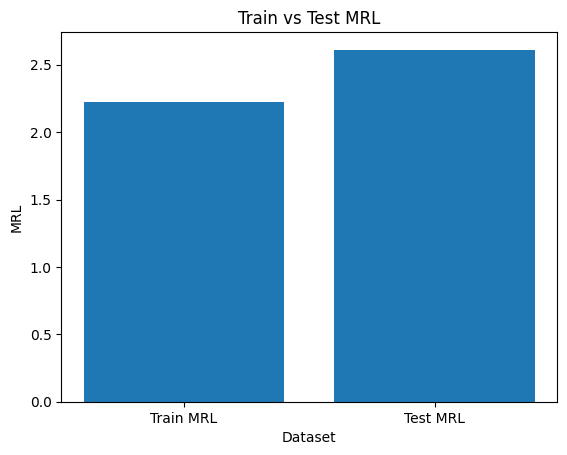

In [17]:
trian_mrl = autoencoder.compute_mrl(X_train)

values = [trian_mrl, test_mrl]
labels = ['Train MRL', 'Test MRL']

plt.bar(labels, values)
plt.xlabel("Dataset")
plt.ylabel("MRL")
plt.title("Train vs Test MRL")

plt.show()

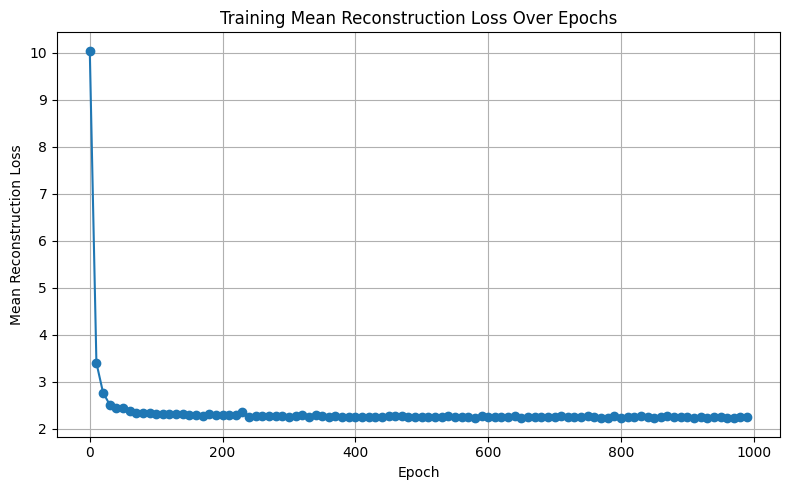

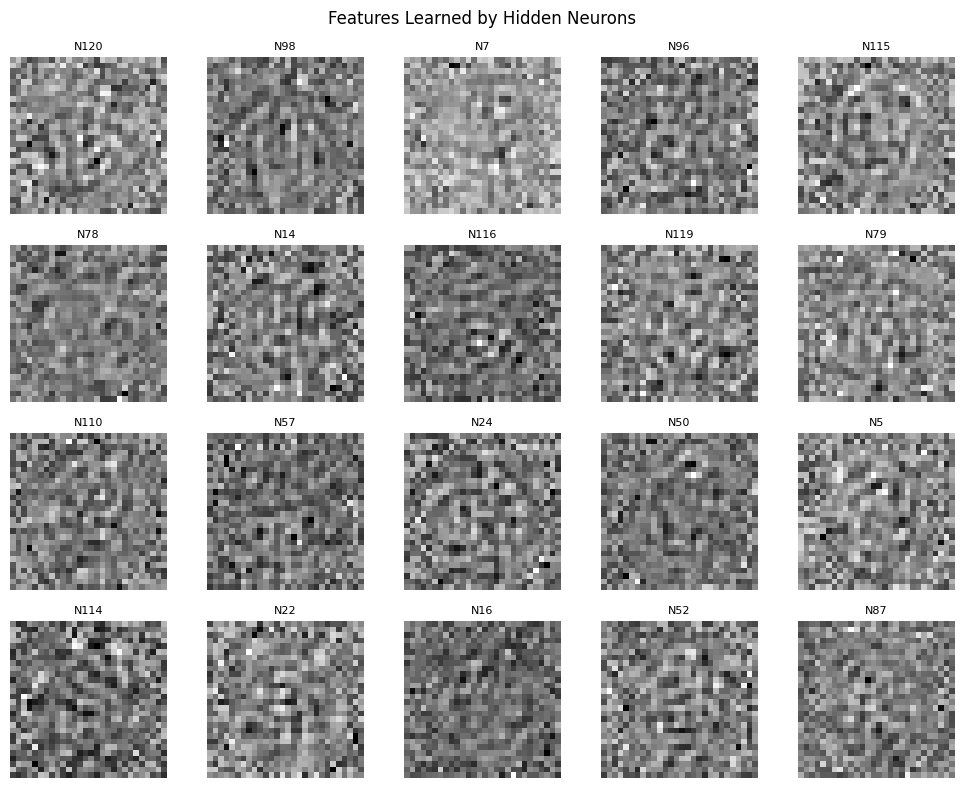

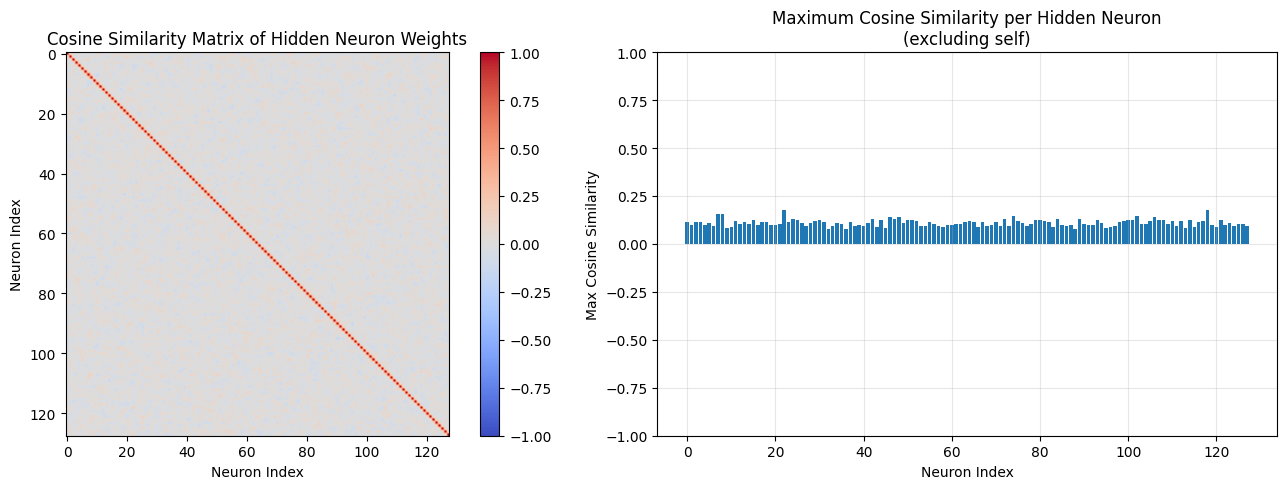

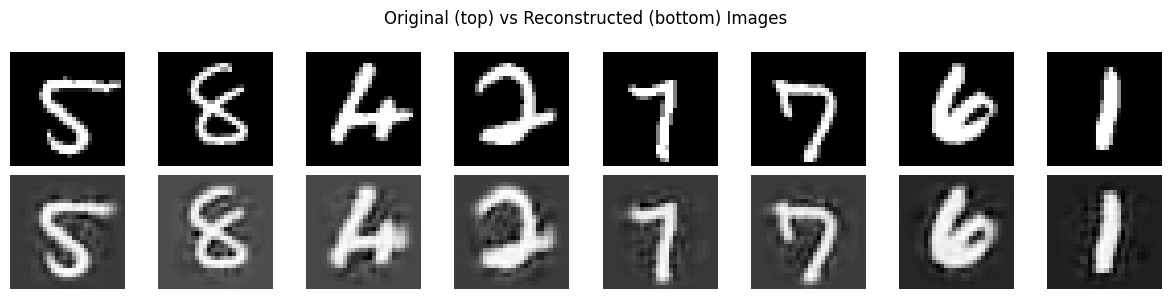

In [13]:
# Visualizations
autoencoder.plot_training_mrl()
neuron_indices = autoencoder.visualize_features(num_features=20)
autoencoder.plot_cosine_similarity()
autoencoder.plot_sample_reconstructions(X_test, num_samples=8)